# MediaPipe

In [2]:
import cv2
import mediapipe as mp
import pandas as pd
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

Doc : https://developers.google.com/edge/mediapipe/solutions/vision/pose_landmarker/python

Here we also need to download a model on the shelf, cf : https://developers.google.com/edge/mediapipe/solutions/vision/pose_landmarker#models </br>
I will be using the Pose landmarker full.

</br>
The model can infer 33 landmarks:

<img src="../assets/pose_landmarks_index.png"
     alt="MediaPipe 33 landmarks"
     width="350">

## Using MediaPipe

In [3]:
model_path = "../models/pose_landmarker_full.task"

options = PoseLandmarkerOptions(base_options = BaseOptions(model_asset_path=model_path), running_mode=VisionRunningMode.VIDEO)

landmarker = mp.tasks.vision.PoseLandmarker.create_from_options(options)

Unlike Yolo, MediaPipe does not directly read a video file. I will use OpenCV to open the .mov and send every frame to MediaPipe.

In [4]:
video_path = "../assets/backflip.mov"

cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

print(success) # OpenCV read the file successfully
print(frame.shape)


True
(1920, 1080, 3)


### Read one frame

In [5]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# np array to mp Image
mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data = frame_rgb)

result = landmarker.detect_for_video(mp_image,timestamp_ms=0)
print(result)

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5955667495727539, y=0.2589302062988281, z=-0.030173562467098236, visibility=0.9995260238647461, presence=0.9998131394386292, name=None), NormalizedLandmark(x=0.5960955619812012, y=0.25018131732940674, z=-0.013221642933785915, visibility=0.9988565444946289, presence=0.9996861219406128, name=None), NormalizedLandmark(x=0.5953032970428467, y=0.24973583221435547, z=-0.013250146992504597, visibility=0.9982821941375732, presence=0.9996519088745117, name=None), NormalizedLandmark(x=0.5942181348800659, y=0.24925555288791656, z=-0.013287766836583614, visibility=0.9989135265350342, presence=0.999591052532196, name=None), NormalizedLandmark(x=0.5941230058670044, y=0.24978607892990112, z=-0.06530360132455826, visibility=0.9992882609367371, presence=0.9997784495353699, name=None), NormalizedLandmark(x=0.5917835831642151, y=0.249064102768898, z=-0.0652535930275917, visibility=0.9992902278900146, presence=0.9997761845588684, name=None), Nor

This model is stateful, meaning it keeps information from previous frames to track the pose over time. Therefore each new frame must have a timestamp greater than the previous one.

### Read multiple frames

In [ ]:
LANDMARKS = ["nose","left_eye_inner","left_eye","left_eye_outer","right_eye_inner","right_eye","right_eye_outer","left_ear","right_ear","mouth_left","mouth_right","left_shoulder","right_shoulder","left_elbow","right_elbow","left_wrist","right_wrist","left_pinky","right_pinky","left_index","right_index","left_thumb","right_thumb","left_hip","right_hip","left_knee","right_knee","left_ankle","right_ankle","left_heel","right_heel","left_foot_index","right_foot_index"]

In [7]:
video_path = "../assets/backflip.mov"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

rows = []
frame_index = 0

with PoseLandmarker.create_from_options(options) as landmarker:

    while True:
    
        success, frame = cap.read()

        if not success:
            break

        # open frame with opencv
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

       # np array to mp Image
        mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data = frame_rgb)

        #timestamp
        timestamp_ms = int(frame_index*1000/fps)

       # inference
        result = landmarker.detect_for_video(mp_image,timestamp_ms=timestamp_ms)

        # pose detected
        if result.pose_landmarks:

            # first person detected
            pose = result.pose_landmarks[0]

            # keeping the 33 landmarks
            for i, landmark in enumerate(pose):

                rows.append({
                    "frame": frame_index,
                    "time": frame_index / fps,
                    "keypoint": LANDMARKS[i],
                    "x": landmark.x,
                    "y": landmark.y,
                    "z": landmark.z,
                    "visibility": landmark.visibility, # model thinks landmark is clearly visible in the image
                    "presence": landmark.presence # model thinks landmark exists in the image
                })


        frame_index += 1

cap.release()

df_mp = pd.DataFrame(rows)

display(df_mp.head())
print(df_mp.shape)

,frame,time,keypoint,x,y,z,visibility,presence
0,0,0.0,nose,0.595567,0.258930,-0.030174,0.999526,0.999813
1,0,0.0,left_eye_inner,0.596096,0.250181,-0.013222,0.998857,0.999686
2,0,0.0,left_eye,0.595303,0.249736,-0.013250,0.998282,0.999652
3,0,0.0,left_eye_outer,0.594218,0.249256,-0.013288,0.998914,0.999591
4,0,0.0,right_eye_inner,0.594123,0.249786,-0.065304,0.999288,0.999778


(3927, 8)


## Visualization

Slight difference from the yolo part, here we visualize both the left and right hip trajectories.

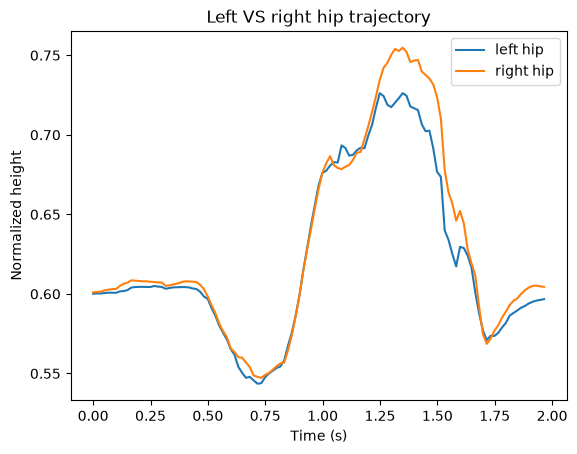

In [10]:
l_hip = df_mp[df_mp["keypoint"] == "left_hip"]
r_hip = df_mp[df_mp["keypoint"] == "right_hip"]

plt.plot(
    l_hip["time"],
    1 - l_hip["y"],
    label="left hip"
)

plt.plot(
    r_hip["time"],
    1 - r_hip["y"],
    label="right hip"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left VS right hip trajectory")
plt.legend()

plt.show()

In [9]:
#df_mp.to_csv("../data/mediapipe_keypoints.csv", index=False)

## Presence VS Visibility

MediaPipe provides two confidence scores for each landmark:
- Visibility: how confident is the model that the landmark is visible in the image.
- Presence: how confident is the model that the landmark is present in the image, regardless of wether it is visible.
</br>

The graph just above, "Left VS right hip trajectory" shows a difference in height between the left and right hip, when there is no such difference in the test video. The thing is that in this video, the camera is on my right hand side, so the left hip landmark is more a presence thing than a visibility thing.
</br>

In this subpart, we will try to assess how reliable each confidence score is.

For more, check: https://github.com/google-ai-edge/mediapipe/blob/master/mediapipe/tasks/python/components/containers/landmark.py

### Confidence scores

We start by looking at the differences in visibility score between the right side and left side, my hypothesis being that there is a big difference.

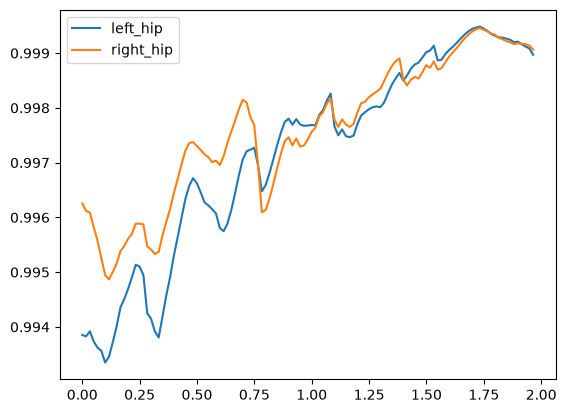

In [ ]:
hips = df_mp[df_mp["keypoint"].isin(["left_hip","right_hip"])]

for name, data in hips.groupby("keypoint"):
    plt.plot(
        data["time"],
        data["visibility"],
        label=name
    )

#plt.xlim(1.1, 1.6)
plt.legend()
plt.show()

No real difference for the hips, model is really confident.

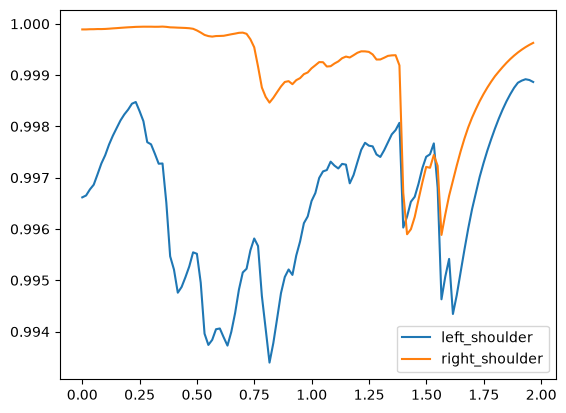

In [21]:
shoulders = df_mp[df_mp["keypoint"].isin(["left_shoulder","right_shoulder"])]

for name, data in shoulders.groupby("keypoint"):
    plt.plot(
        data["time"],
        data["visibility"],
        label=name
    )

#plt.xlim(1.1, 1.6)
plt.legend()
plt.show()

Model is also really confident for the shoulders.

But what about the differences between visibility and presence ?

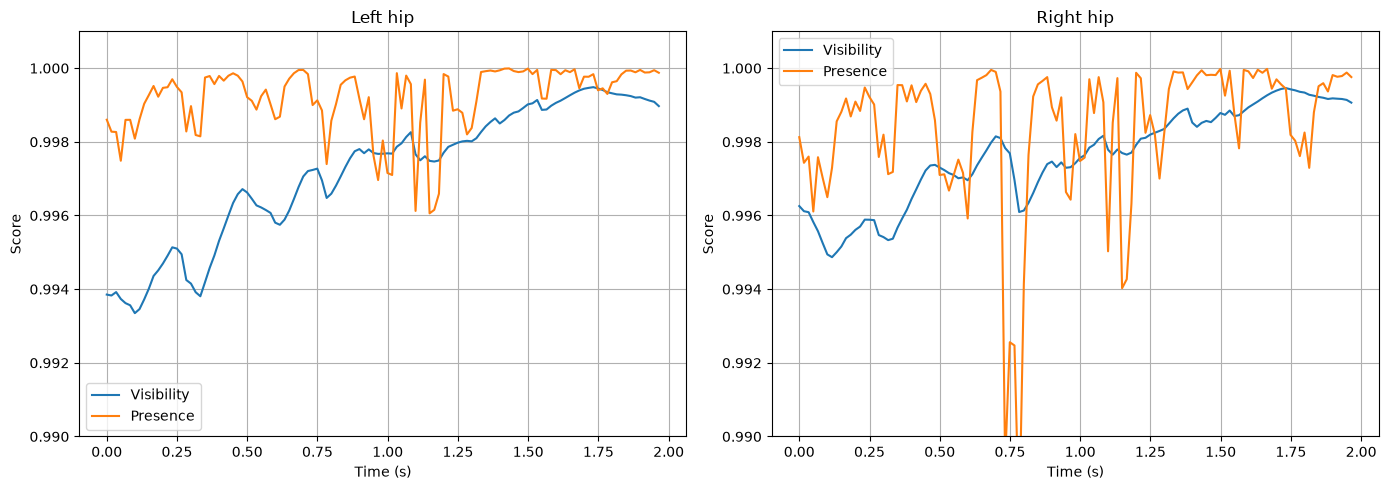

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, side in zip(axes, ["left", "right"]):

    data = df_mp[
        df_mp["keypoint"] == f"{side}_hip"
    ]

    ax.plot(
        data["time"],
        data["visibility"],
        label="Visibility"
    )

    ax.plot(
        data["time"],
        data["presence"],
        label="Presence"
    )

    ax.set_title(f"{side.capitalize()} hip")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Score")
    ax.set_ylim(0.990, 1.001)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

We can see that wether its visibility or presence the model is really confident.

### High confidence, not accuracy

Lets plot again the trajectory of hips and shoulders during the backflip.

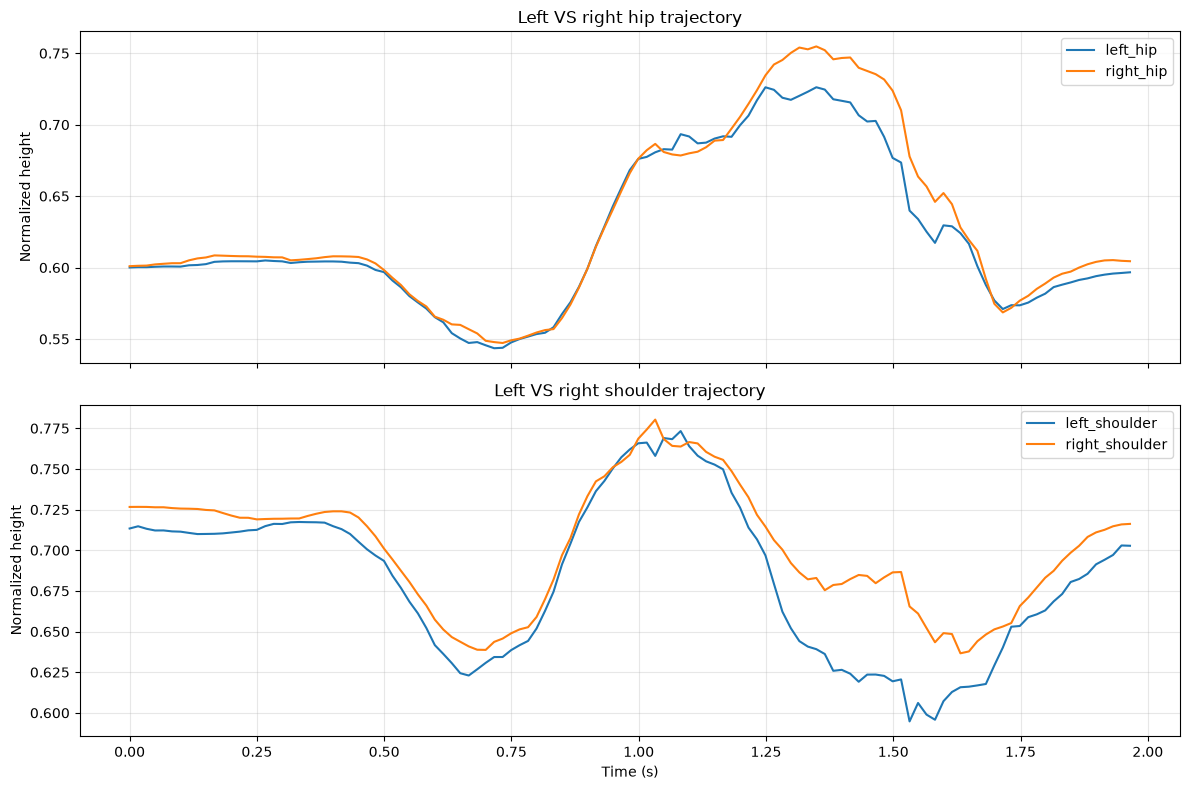

In [29]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

keypoints = {
    "hip": ["left_hip", "right_hip"],
    "shoulder": ["left_shoulder", "right_shoulder"]
}

for ax, (joint, names) in zip(axs, keypoints.items()):

    data_filtered = df_mp[df_mp["keypoint"].isin(names)]

    for name, data in data_filtered.groupby("keypoint"):
        ax.plot(
            data["time"],
            1 - data["y"],
            label=name
        )

    ax.set_ylabel("Normalized height")
    ax.set_title(f"Left VS right {joint} trajectory")
    ax.legend()
    ax.grid(alpha=0.3)

axs[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

Compare it to a screenshot of any frame between 1.25 and 1.5. We see the points are not so accurate, with each orange arrow reprenting a right landmark and each blue arrow a left landmark.

<img src="../assets/mp_prediction/leftandrightcomparison.paint"
     alt="MediaPipe 33 landmarks"
     width="350">

To be honnest I am not completly sure to completly grasp the differences between visibility and presence, I mean like the high confidence score of presence makes sense, but I am a bit surprised by the visibility, especially when one side of the body is occluded. Anyway, neither of these scores tells us wether the predicted landmark positions are accurate, so we will not rely on them.